# Cross Validation and Regularization

## Knowledge Map for This Guide

1. **Part 1 - Why Cross-Validation (CV) Matters**: statistical reliability, bias-variance perspective, and why one split is not enough.
2. **Part 2 - Manual K-Fold Workflow**: build intuition by explicitly looping through folds.
3. **Part 3 - Pipelines + Automated CV**: reduce code complexity and leakage risk with `Pipeline` and `cross_val_predict`.
4. **Part 4 - Hyperparameter Tuning with Lasso**: explore complexity control through `alpha`.
5. **Part 5 - Ridge + Feature Interpretation**: compare regularizers and inspect learned coefficients.
6. **Part 6 - Workflow Automation with `GridSearchCV`**: search over model settings with cross-validation in one object.

Use each part as a continuation of the previous one: we move from intuition, to implementation, to automation.

## Learning objectives

By the end of this lesson, you will be able to:

* Chain multiple data processing steps together using `Pipeline`
* Use the `KFolds` object to split data into multiple folds.
* Perform cross validation using SciKit Learn with `cross_val_predict` and `GridSearchCV`


In [1]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

#%pip install numpy pandas matplotlib scikit-learn
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [2]:
boston = pickle.load(open('data/boston_housing_clean.pickle', "rb" ))

print("Keys in the boston dictionary:", boston.keys())
# The boston dictionary contains two keys: 'dataframe' and 'description'.
boston_data = boston['dataframe']
boston_description = boston['description']

Keys in the boston dictionary: dict_keys(['dataframe', 'description'])


In [3]:
boston_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### About the Dataset: Boston Housing

The `boston_data` DataFrame contains **506 observations** of Boston-area census tracts from the 1970s. Our target is `MEDV` — the **median value of owner-occupied homes** (in $1000s). The 13 predictor features include:

| Feature | Description |
|---------|-------------|
| `CRIM` | Per-capita crime rate by town |
| `ZN` | Proportion of residential land zoned for large lots |
| `INDUS` | Proportion of non-retail business acres |
| `CHAS` | Charles River dummy (1 if tract bounds river) |
| `NOX` | Nitric oxide concentration (parts per 10 million) |
| `RM` | Average number of rooms per dwelling |
| `AGE` | Proportion of owner-occupied units built before 1940 |
| `DIS` | Weighted distance to five Boston employment centers |
| `RAD` | Index of accessibility to radial highways |
| `TAX` | Full-value property-tax rate per $10,000 |
| `PTRATIO` | Pupil-teacher ratio by town |
| `B` | Proportion of residents of African American descent (Brookes index) |
| `LSTAT` | % lower status of the population |

This dataset is a classic regression benchmark. Our goal throughout this notebook: predict `MEDV` from these 13 features, and learn to evaluate that prediction *reliably* using cross-validation.

### Discussion: Implementing K-Fold from Scratch

Suppose we want to use Linear Regression on our dataset and estimate — via $R^2$ — how well the model generalizes to unseen data.

Suppose the data is split into **three folds**: Fold 1, Fold 2, and Fold 3.

Think through the steps *before* looking at the code below:

- What data is used for training in each round? What data is held out for testing?
- How many times do we instantiate/fit the model?
- What do you do with the three scores you collect?

---

## Part 1: Why Cross-Validation Matters

### The Problem with a Single Train-Test Split

Imagine evaluating a model on just one held-out test set. If the partition happened to put "easy" samples in the test set, your $R^2$ will look artificially high. If you got a "hard" split, it will look artificially low. **You have no way to distinguish luck from skill.**

Cross-validation solves this by using **every row as test data exactly once**. With $K = 3$ folds:

| Round | Train on | Test on | Produces |
|-------|----------|---------|----------|
| 1 | Folds 2 + 3 | Fold 1 | $R^2_1$ |
| 2 | Folds 1 + 3 | Fold 2 | $R^2_2$ |
| 3 | Folds 1 + 2 | Fold 3 | $R^2_3$ |

**CV score = mean($R^2_1$, $R^2_2$, $R^2_3$)** — statistically more reliable than any single split because you cannot get lucky on *all* splits simultaneously.

### The Bias-Variance Tradeoff

The reason we need cross-validation to make good modeling decisions is the bias-variance tradeoff. As you increase model complexity (higher polynomial degree, more features, less regularization), two competing forces act on your error:

$$\text{Expected Test Error} = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2_\varepsilon}_{\text{irreducible}}$$

| Term | High when... | Symptom |
|------|-------------|---------|
| **Bias²** | Model too simple | Both train and test error are high |
| **Variance** | Model too complex | Train error is low, test error is high |
| **Irreducible noise** | Always | Cannot be reduced by any model |

- **Underfitting** (high bias): model learns too little from the data — it can't even fit the training set well.
- **Overfitting** (high variance): model memorizes training quirks — it fits training data perfectly but fails on new data.

Cross-validation is the tool that locates the "just right" complexity: the point on the bias-variance curve where test error is minimized. A single train-test split can land you at the wrong point just by chance.

#### Implementing K-Fold: The `KFold` Object

The [`KFold`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) object in scikit-learn manages the index-splitting logic. Key parameters are:
| Parameter | Effect |
|-----------|--------|
| `n_splits=n` | Splits the data into n roughly equal folds ($\frac{n-1}{n}$ train, $\frac{1}{n}$ test each round) |
| `shuffle` | Randomizes row order before splitting — setting it `True` prevents folds from being accidentally ordered by time, geography, etc. |
| `random_state` | Seeds the shuffle so results are reproducible |

In [4]:
X = boston_data.drop('MEDV', axis=1)
y = boston_data.MEDV

kf = KFold(n_splits=3, shuffle=True, random_state=72018)

Calling `kf.split(X)` returns a **generator** — each iteration yields a `(train_indices, test_indices)` tuple of NumPy arrays. Notice this tells you *which rows* to use, not the data itself.

In [5]:
for train_index, test_index in kf.split(X):
    print("Train index:", train_index[:10], len(train_index))
    print("Test index:",test_index[:10], len(test_index))
    print('')

Train index: [ 1  3  4  5  7  8 10 11 12 13] 337
Test index: [ 0  2  6  9 15 17 19 23 25 26] 169

Train index: [ 0  2  6  9 10 11 12 13 15 17] 337
Test index: [ 1  3  4  5  7  8 14 16 22 27] 169

Train index: [0 1 2 3 4 5 6 7 8 9] 338
Test index: [10 11 12 13 18 20 21 24 28 31] 168



The output above shows three fold pairs. The train set has ~337 rows and the test set has ~169 rows each round — roughly a 2:1 ratio. 

Notice that the **test sets are non-overlapping**: no single row appears in more than one test fold. The training sets do share rows across folds, which is expected.

Now let's use these index arrays to run the actual CV loop manually:

In [6]:
#from sklearn.metrics import r2_score, mean_squared_error 
# We don't need to import these again since we imported them in the beginning of the notebook.

scores = []
lr = LinearRegression()

for train_index, test_index in kf.split(X):
    X_train, X_test, y_train, y_test = (
    X.iloc[train_index, :], X.iloc[test_index, :], 
    y[train_index], y[test_index]
    )
    
    lr.fit(X_train, y_train)
        
    y_pred = lr.predict(X_test)

    score = r2_score(y_test.values, y_pred)
    
    scores.append(score)
    
print("R^2 scores:", scores)

cv_estimate = np.mean(scores)   # more trustworthy than any single score
print("\nCross-validation mean score:", cv_estimate)

R^2 scores: [0.671934879847276, 0.7485020059212366, 0.6976807323597755]

Cross-validation mean score: 0.7060392060427626


The `scores` list now holds three $R^2$ values — one per fold. They will not be identical, because different subsets of the data expose different patterns. That variability is **precisely why** we take the mean.

A bit cumbersome to write, but do-able. Now consider: what if we also want to scale our data before fitting? That makes the loop significantly messier — and opens the door to **data leakage**, a subtle but serious error.

### Discussion: Why Does Scaling Complicate the K-Fold Loop?

Before writing the code, think through this crucial constraint:

**The scaler must be fit only on training data.**

`StandardScaler` computes the mean $\mu$ and standard deviation $\sigma$ of whatever data you call `.fit()` on, then scales as:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

If we compute $\mu$ and $\sigma$ from *all* rows — including the test fold — we are smuggling information from the held-out set into the training process. This is called **data leakage**, and it creates overly optimistic accuracy estimates that will not hold up on truly new data.

The correct procedure for each fold is:
1. `scaler.fit_transform(X_train)` — **fit and transform** on training data (learns $\mu$, $\sigma$ from training rows only)
2. `scaler.transform(X_test)` — **transform only** on test data, applying the training-set $\mu$ and $\sigma$

*Pause here and think through what the loop should look like, then proceed to the next part.*

---

## Part 2: Manual K-Fold Workflow — Adding Preprocessing

We add one preprocessing step (`StandardScaler`) to the loop. The critical asymmetry to internalize:

| Call | When | Why |
|------|------|-----|
| `scaler.fit_transform(X_train)` | Every fold, on training data | Learns $\mu$ and $\sigma$ from training rows; also applies the transformation |
| `scaler.transform(X_test)` | Every fold, on test data | Applies the **training-set** $\mu$/$\sigma$ — no refitting! |

Violating this rule (calling `fit_transform` on test data too) would cause data leakage. The scaler would secretly "see" the test distribution, making our held-out score artificially high — we'd think the model is better than it is.

### Coding this up


In [7]:
scores = []

lr = LinearRegression()
s = StandardScaler()

for train_index, test_index in kf.split(X):
    X_train, X_test, y_train, y_test = (
        X.iloc[train_index, :], X.iloc[test_index, :], 
        y[train_index], y[test_index]
    )
    
    X_train_s = s.fit_transform(X_train)
    lr.fit(X_train_s, y_train)
    X_test_s = s.transform(X_test)
    y_pred = lr.predict(X_test_s)

    score = r2_score(y_test.values, y_pred)
    scores.append(score)

scores

[0.6719348798472717, 0.748502005921238, 0.6976807323597745]

*(Same scores as before — and that is expected for this specific case.)*

Ordinary least-squares linear regression is **scale-invariant**: multiplying all features by a constant shifts the learned coefficients by the inverse constant, so predictions and $R^2$ are unchanged. Scaling does not help or hurt OLS.

However, once we move to **regularized models** (Lasso, Ridge) in Part 4, scaling becomes **essential**. Regularization penalizes large coefficient values. If one feature has values in the thousands and another has values near zero, the large-valued feature's coefficient will naturally be smaller — and the penalty will treat the two features unequally. Scaling puts all features on the same footing before the penalty is applied.

### The Problem with Writing This Out Manually

The loop above has two layers of friction:

1. **Boilerplate per step**: for every preprocessing step, we must call `fit_transform` on train and `transform` on test — by hand, every fold.
2. **Fragility when experimenting**: if we want to try a different scaler, add polynomial features, or swap the model, we rewrite the entire loop. Easy to introduce a bug (like accidentally `fit_transform`-ing the test set).

Scikit-learn's `Pipeline` abstraction eliminates both problems.

---

## Part 3: Pipelines and Automated Cross-Validation

`Pipeline` chains transformers and a final estimator into a single object. When we pass a `Pipeline` to `cross_val_predict`, the entire manual loop from Part 2 collapses to two lines — and leakage is impossible by construction.

**How Pipeline prevents leakage automatically:**

```
For each fold (internally):
    pipeline.fit(X_train, y_train) ← scaler sees ONLY training-fold rows
    pipeline.predict(X_test)      ← scaler applies training-fold stats to test
```

We no longer have to manually separate `fit_transform` from `transform`. The pipeline does it correctly every time.

`Pipeline` lets you chain together multiple processing steps where each step has a `fit` method.

**Rules:**
- Every step *except the last* must have a `fit_transform` method (transformer).
- The last step only needs `fit` / `predict` (estimator).
- Steps are processed **left to right**: the output of step $i$ is the input to step $i+1$.

```python
pipeline.fit(X, y)
# internally: X → scaler.fit_transform(X) → lr.fit(X_scaled, y)

pipeline.predict(X_new)
# internally: X_new → scaler.transform(X_new) → lr.predict(X_scaled_new)
```

### Combine Multiple Processing Steps into a `Pipeline`

A pipeline is defined as a list of `("name", object)` tuples:
- The **name** string is optional but useful — it let us reference a specific step by name later (e.g. `estimator.named_steps["scaler"]`) and let us tune step-specific hyperparameters in `GridSearchCV` using the `"stepname__param"` syntax (covered in Part 6).
- The **object** is any scikit-learn transformer or estimator.

Think of it as a factory line: raw data enters one end, processed predictions come out the other, with every step correctly fit/transformed in sequence.

In [8]:
s = StandardScaler()
lr = LinearRegression()

estimator = Pipeline([("scaler", s), ("regression", lr)])

### `cross_val_predict`: Out-of-Bag Predictions

[`cross_val_predict`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html) runs K-fold CV internally and collects predictions:

- For each fold: fits the pipeline on the training folds, predicts on the held-out fold.
- Returns a **single array with the same length as `X`**, where each row's prediction was made by a model that **never saw that row during training**.

These are called **out-of-bag (OOB) predictions**. Computing `r2_score(y, predictions)` on OOB predictions gives an unbiased estimate of generalization performance — equivalent to what we'd get by averaging the per-fold scores.

> **`cross_val_score` vs `cross_val_predict`:** 

>`cross_val_score` returns one score per fold and we average them. 

>`cross_val_predict` returns one *prediction per row*, and we then evaluate those predictions ourselves with `r2_score`. Both give roughly the same number, but `cross_val_predict` also gives the full predicted array — useful for diagnosing where the model fails.

In [9]:
kf

KFold(n_splits=3, random_state=72018, shuffle=True)

### Why We Score These Predictions

`cross_val_predict` gives one out-of-fold prediction per row (each prediction is made by a model that did not train on that row).
Computing `r2_score(y, predictions)` therefore gives a cross-validated performance estimate on the full dataset, which we can compare to the manual K-fold mean score from earlier.

In [10]:
predictions = cross_val_predict(estimator, X, y, cv=kf)
r2_score(y, predictions)

0.7063531064161561

In [11]:
np.mean(scores) # almost identical!

np.float64(0.7060392060427615)

**Important nuance about `cross_val_predict`:**

The predictions for each row are made by a model trained *without* that row. Effectively we trained 3 different models (one per fold). After the call finishes, `estimator` is **still unfitted** — `cross_val_predict` used it as a template to create temporary copies inside each fold; it did not modify the original object.

This creates a two-step workflow:

| Step | Purpose | Code |
|------|---------|------|
| 1. Evaluate | Get an unbiased CV score to compare models | `predictions = cross_val_predict(estimator, X, y, cv=kf)` |
| 2. Deploy | Train a final model on *all* available data | `estimator.fit(X, y)` — then use for new predictions |

Do **not** call `estimator.predict(X_new)` after `cross_val_predict` without first calling `.fit()` — the estimator is not fitted and will raise a `NotFittedError`.

#### Below is our full workflow from the beginning so far:

`raw CSV` -> `data = pd.read_csv(...)`
`data` -> `X = data.drop(target)` and `y = data[target]`

Set up tools (independent configuration, not data-dependent):
`kf = KFold(...)`  (evaluation rule: how to split)
`estimator = Pipeline([("scaler", s), ("regression", lr)])`  (model recipe: what to train)

**Phase A - Selection/Evaluation (uses `kf`):**
`X, y, estimator, kf` -> `predictions = cross_val_predict(estimator, X, y, cv=kf)`
`y, predictions` -> `cv_r2 = r2_score(y, predictions)`

This score helps us choose/justify a model setting; this step does **not** produce a deployable fitted estimator.

How the best configuration is chosen:
We try multiple candidate configurations (for example, different models, polynomial degree, or `alpha`) and compute one CV score per candidate.
Select the candidate with the highest CV score (for example, `best_idx = np.argmax(cv_scores)`), and call that winner `best_estimator_config`.

**Phase B - Final Training/Deployment (does not use `kf`):**
`X, y, best_estimator_config` -> `fitted_estimator = best_estimator_config.fit(X, y)`
`X_new, fitted_estimator` -> `y_new = fitted_estimator.predict(X_new)`
This is the model we use/deploy/ship.

---

## Part 4: Hyperparameter Tuning with Lasso Regularization

### Parameters vs. Hyperparameters

Parameters are the output of the learning algorithm. Hyperparameters are the *settings* of the learning algorithm. Choosing the right hyperparameters is called **hyperparameter tuning**, and the only reliable way to do it is with cross-validation — otherwise you risk overfitting them too.

| Concept | Who sets it? | Example |
|---------|-------------|---------|
| **Parameter** | Learned automatically from training data | Regression coefficients $\hat{\beta}$ |
| **Hyperparameter** | Set by the practitioner, you and me, **before** training | Regularization strength `alpha`, polynomial degree |

### Lasso Regression (L1 Regularization)

Standard Ordinary Least Squares (OLS) regression minimizes residual sum of squares. **Lasso** adds a penalty proportional to the **sum of absolute values** of coefficients (the L1 norm).

The `alpha` hyperparameter controls the trade-off:

| `alpha` value | Effect |
|--------------|--------|
| Very small ($\to 0$) | Penalty disappears → behaves like OLS → may overfit if model is complex |
| Moderate | Coefficients shrink → simpler model → better generalization |
| Very large | Almost all coefficients shrink to **exactly zero** → underfitting |

Lasso's L1 geometry forces many coefficients to become **exactly zero** at the solution, making it a natural feature selector. Features with zero coefficient are effectively removed from the model.

### Definition

**Hyperparameter tuning** uses cross-validation (or a hold-out set) to find which hyperparameters are most likely to produce a model that *generalizes* well outside the training sample. For each candidate value of `alpha`, we run full cross-validation and record the CV score. The `alpha` that yields the best CV score is selected.

### Mechanics: Logarithmic Search with `geomspace`

Regularization strength (`alpha`) is typically searched on a **logarithmic scale**, not a linear one. The reason: the model's behavior changes dramatically between, say, `alpha=0.001` and `alpha=0.01`, but very little between `alpha=100` and `alpha=101`. Logarithmic spacing ensures you explore interesting parts of the range.

```python
np.geomspace(1, 1000, num=4)
# array([   1.,   10.,  100., 1000.])
```

Every value is a constant *multiple* of the previous one (here, ×10). You can think of it as `np.logspace` but specifying start/end values instead of exponents.

Use this function to generate a list of 10 `alpha` values spanning from $10^{-9}$ to $10^0$:

In [12]:
lasso_alphas = np.geomspace(1e-9, 1e0, num=10)
lasso_alphas

array([1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02,
       1.e-01, 1.e+00])

The loop below sweeps over each candidate `alpha`. For every value:

1. Creates a `Lasso(alpha=alpha)` instance
2. Wraps it in a `Pipeline` with `StandardScaler` (scaling is necessary here — Lasso's penalty is scale-dependent)
3. Runs 3-fold `cross_val_predict` to get OOB predictions
4. Computes and stores the OOB $R^2$

After the loop we'll have 10 scores. 

**Plotting alpha (log scale) vs. $R^2$** will reveal the classic tradeoff curve: low alpha → complex model → possible overfit (lower CV score); moderate alpha → just-right complexity → peak CV score; high alpha → underfit (lower CV score).

In [13]:
lasso_scores = []
coefs = []
for alpha in lasso_alphas:
    las = Lasso(alpha=alpha, max_iter=100000)
    
    estimator = Pipeline([
        ("scaler", s),
        ("lasso_regression", las)])

    predictions = cross_val_predict(estimator, X, y, cv = kf)
    score = r2_score(y, predictions)
    lasso_scores.append(score)

lasso_best_alpha_idx = np.argmax(lasso_scores)
lasso_best_alpha = lasso_alphas[lasso_best_alpha_idx]
lasso_best_score = lasso_scores[lasso_best_alpha_idx]

print(f"Best alpha: {lasso_best_alpha}")
print(f"Best cross-validated R^2: {lasso_best_score:.4f}")

Best alpha: 0.01
Best cross-validated R^2: 0.7071


In [14]:
# Pair each candidate alpha with its cross-validated R^2 score.
# Look for the alpha where the score is highest (this should match the printed best alpha).
list(zip(lasso_alphas, lasso_scores))

[(np.float64(1e-09), 0.7063531064981925),
 (np.float64(1e-08), 0.7063531072356071),
 (np.float64(1e-07), 0.7063531145602442),
 (np.float64(1e-06), 0.7063531882052064),
 (np.float64(1e-05), 0.7063539165191507),
 (np.float64(0.0001), 0.706361268093463),
 (np.float64(0.001), 0.7064334670415461),
 (np.float64(0.01), 0.7070865958083232),
 (np.float64(0.1), 0.705838151167185),
 (np.float64(1.0), 0.6512724532884887)]

In [15]:
# Fit Lasso with a very small alpha (almost no regularization).
# Notice many non-zero coefficients with larger magnitudes, similar to OLS behavior.
Lasso(alpha=1e-6).fit(X, y).coef_

array([-1.07170372e-01,  4.63952623e-02,  2.08588308e-02,  2.68854318e+00,
       -1.77954207e+01,  3.80475296e+00,  7.50802707e-04, -1.47575348e+00,
        3.05654279e-01, -1.23293755e-02, -9.53459908e-01,  9.39253013e-03,
       -5.25467196e-01])

In [16]:
# Fit Lasso with a much larger alpha (strong regularization).
# Compare with the previous cell: more coefficients should shrink toward zero.
Lasso(alpha=1.0).fit(X, y).coef_

array([-0.06342255,  0.04916867, -0.        ,  0.        , -0.        ,
        0.94678567,  0.02092737, -0.66900864,  0.26417501, -0.01520915,
       -0.72319901,  0.00829117, -0.76143296])

### Interpreting the Coefficients Above

- Each value in `.coef_` corresponds to one feature column in `X`, in the same column order.
- The intercept is not included in `.coef_`; it is stored separately in `.intercept_`.
- In these two cells, we fit Lasso directly on unscaled `X`, so coefficient magnitudes are influenced by feature units and are not directly comparable across columns.

To inspect names and coefficients together, you can pair them with `X.columns` (for example, by building a small DataFrame).

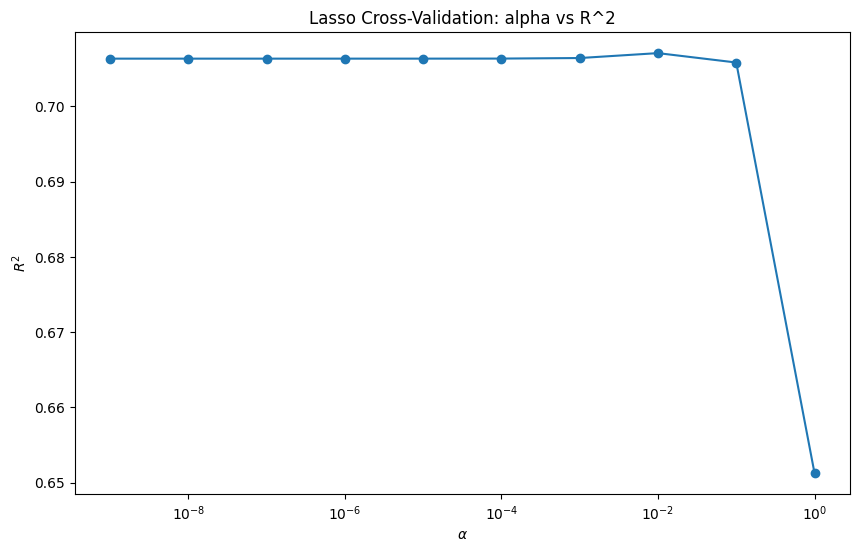

In [17]:
plt.figure(figsize=(10,6))
plt.semilogx(lasso_alphas, lasso_scores, '-o')
plt.xlabel('$\\alpha$')
plt.ylabel('$R^2$')
plt.title('Lasso Cross-Validation: alpha vs R^2');

### Extending Lasso with Polynomial Features

With 13 original features, `PolynomialFeatures(degree=2)` creates:
- All squared terms: $\text{CRIM}^2$, $\text{RM}^2$, ...
- All pairwise interaction terms: $\text{RM} \times \text{LSTAT}$, $\text{NOX} \times \text{DIS}$, ...
- Result: from 13 features → **104 features** (including the constant)

This dramatically increases model expressiveness — the linear model can now capture curved relationships and feature interactions. But with 104 features on 506 rows, the risk of overfitting increases too. That's why Lasso regularization is especially valuable here: it will zero out the many irrelevant or redundant polynomial terms, keeping only the truly predictive ones.

### Exercise

Add `PolynomialFeatures` to this `Pipeline` and re-run the cross-validation.

**Hint #1:** Pipeline steps are applied left to right. Think about the right order: should you create polynomial terms before or after scaling?

**Hint #2:** You should see a significant increase in CV accuracy from adding polynomial features.

In [18]:
pf = PolynomialFeatures(degree=2)
poly_lasso_scores = []

poly_lasso_alphas = np.geomspace(0.001, 10, 5)
for alpha in poly_lasso_alphas:
    las = Lasso(alpha=alpha, max_iter=100000)
    estimator = Pipeline([
        ("make_higher_degree", pf),
        ("scaler", s),
        ("lasso_regression", las)])
    predictions = cross_val_predict(estimator, X, y, cv=kf)
    score = r2_score(y, predictions)
    
    poly_lasso_scores.append(score)
poly_lasso_scores

[0.8465056899967163,
 0.8552553819994735,
 0.812453647729607,
 0.7090474482089187,
 -0.000616160136140298]

Using the values from the previous cell, the following will work:


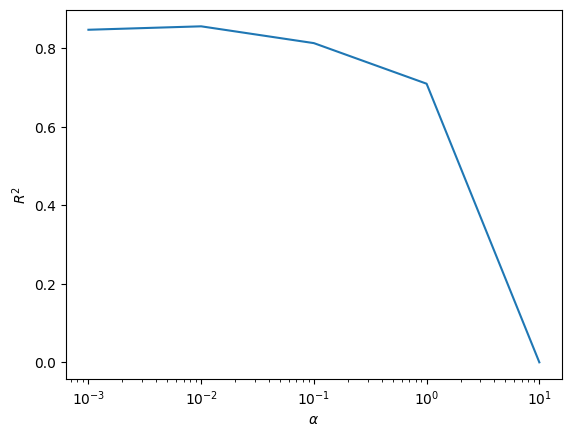

In [19]:
plt.semilogx(poly_lasso_alphas, poly_lasso_scores)
plt.xlabel('$\\alpha$')
plt.ylabel('$R^2$');

In [20]:
# Once we have found the hyperparameter (alpha~1e-2=0.01)
# make the model and train it on ALL the data
# Then release it into the wild .....
best_estimator = Pipeline([
                    ("make_higher_degree", PolynomialFeatures(degree=2)),
                    ("scaler", s),
                    ("lasso_regression", Lasso(alpha=0.01, max_iter=10000))])

best_estimator.fit(X, y)
best_estimator.score(X, y)

0.9032551408154246

**Why fit on *all* the data now?**

Cross-validation was used purely for *evaluation* — to find the best `alpha`. Once we have that, we train the final model on all 506 rows. Using more training data generally yields better-fitting coefficients, because the model has more signal to learn from. This is the standard two-step workflow:

1. **Tune**: use CV to identify the best hyperparameter(s).
2. **Train**: refit the same pipeline with those hyperparameters on all available data — this is the model you deploy.

Note that `best_estimator.score(X, y)` reports in-sample $R^2$ here (train = test = all data). It will be higher than the CV score, and that's expected — it measures fit, not generalization.

In [21]:
best_estimator.named_steps["lasso_regression"].coef_

array([ 0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        4.61127587e+00,  0.00000000e+00,  6.24240557e-01,  0.00000000e+00,
       -7.22878514e+00,  9.74968793e+00,  0.00000000e+00,  0.00000000e+00,
        6.34548325e-01,  0.00000000e+00,  9.95741679e-01, -5.51374291e-03,
       -0.00000000e+00,  2.44370838e+00, -2.40444044e+00, -0.00000000e+00,
       -0.00000000e+00, -2.23044443e-01, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -2.88128934e-01,  5.17203914e-01,  3.07715719e-01,
       -3.39853933e-01, -9.86590910e-02, -0.00000000e+00,  2.72847487e-01,
       -0.00000000e+00, -6.39829763e-01, -3.16474346e-01,  1.44555554e+00,
        0.00000000e+00, -0.00000000e+00, -8.84630187e-01,  1.32081558e+00,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  2.63148300e+00,
       -2.62941147e-01,  0.00000000e+00,  9.08410143e-01, -8.17144528e-01,
        0.00000000e+00, -4.31628234e+00,  5.53254405e-01, -2.91912598e+00,
       -4.68486241e+00,  

### Exercise: Repeat with Ridge Regression

We now move from Lasso (L1) to Ridge (L2). The exercise is structurally identical, but the results and coefficient behavior are different. Complete the Ridge hyperparameter sweep before reading Part 5.

Which model, `Ridge` or `Lasso`, performs best with its optimal hyperparameter on the Boston dataset?

## Part 5: Ridge Regression and Coefficient Interpretation

### Ridge Regression (L2 Regularization)

**Ridge** adds a penalty proportional to the **sum of squared values** of coefficients (the L2 norm):

$$\min_\beta \|y - X\beta\|_2^2 + \alpha \sum_j \beta_j^2$$

### Lasso vs. Ridge: Key Differences

| Property | Lasso (L1) | Ridge (L2) |
|----------|-----------|------------|
| Penalty | $\alpha \sum_j |\beta_j|$ | $\alpha \sum_j \beta_j^2$ |
| Effect on small coefficients | Drives them exactly to **zero** | Shrinks them toward zero, but rarely exact zero |
| Feature selection | ✅ Built-in (sparse solution) | ❌ Keeps all features, just smaller |
| Best when | Many irrelevant features to remove | All features contribute something small |
| Geometric intuition | L1 "diamond" constraint — corners create sparsity | L2 "sphere" constraint — smooth surface, no corners |

With 104 polynomial features (degree-2 expansions of 13 original features), Ridge will keep all 104 but shrink less important ones. After fitting, sorting the coefficients by magnitude reveals which features and interactions the model considers most predictive of home values.

Text(0, 0.5, '$R^2$')

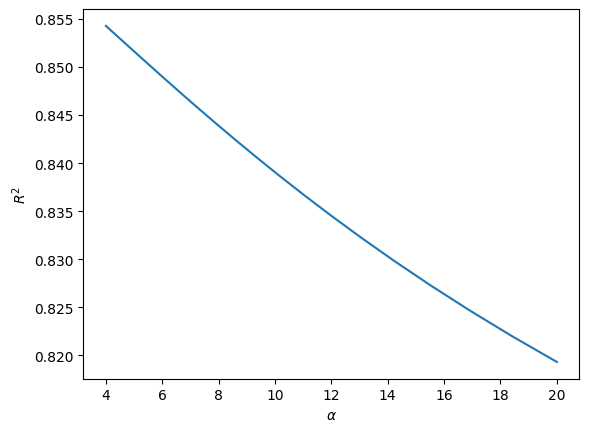

In [22]:
pf = PolynomialFeatures(degree=2)
scores = []

alphas = np.geomspace(4, 20, 20)
for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=100000)

    estimator = Pipeline([
        ("polynomial_features", pf),
        ("scaler", s),
        ("ridge_regression", ridge)])

    predictions = cross_val_predict(estimator, X, y, cv = kf)
    score = r2_score(y, predictions)
    scores.append(score)
plt.plot(alphas, scores)
plt.xlabel('$\\alpha$')
plt.ylabel('$R^2$')

**Conclusion:** Both Lasso and Ridge with properly tuned `alpha` significantly outperform plain OLS on this dataset. This is because polynomial features introduce many interaction terms, and without regularization the model overfits heavily ($R^2$ on test collapses). Regularization keeps the coefficient magnitudes in check.

**Which is better: Lasso or Ridge?**

On this dataset they tend to be comparable, but they make different trade-offs:
- If you believe only a **few** features truly drive the outcome → Lasso's sparsity gives a cleaner, more interpretable model.
- If you believe **most** features contribute something small → Ridge distributes credit across them all.
- When unsure: try both and compare CV scores. In practice, `ElasticNet` combines both penalties and often wins.

Next: we use the best-performing model to inspect which features and interactions the model found most important.

### Exercise: Inspect Feature Importances from the Best Model

**Why does this matter?** Cross-validation told us *how well* the model predicts. Coefficient analysis tells us *what* the model learned. Together they answer: "does this model generalize well, and do its learned relationships make domain sense?"

A large positive coefficient on feature $j$ means: holding all else constant, a one-unit increase in $x_j$ is associated with a `coef_j` increase in predicted home value. With polynomial features, these units are in the transformed space (e.g. $\text{RM}^2$ is unusual — rooms²), so interpret them carefully.

For your best overall hyperparameter:

1. Standardize the data
2. Fit the final model on the entire dataset
3. Extract and sort coefficients to find which polynomial features drive the prediction

**Getting feature names from `PolynomialFeatures`:**
```python
# Get names like "x0", "x1 x2", "x3^2" for the transformed features
pf.get_feature_names_out(input_features=X.columns.tolist())
```

Build a DataFrame pairing feature names with coefficients:
```python
df_importances = pd.DataFrame({
    "feature": pf.get_feature_names_out(X.columns.tolist()),
    "coefficient": model.coef_
}).sort_values("coefficient")
```

**To map `x0`, `x1`, ... back to original column names:**
```python
dict(zip(range(len(X.columns)), X.columns))
# {0: 'CRIM', 1: 'ZN', 2: 'INDUS', ...}
```

So `x5` and `x5^2` refer to `RM` and `RM²` — the average number of rooms.

In [ ]:
# Once we have found the hyperparameter (alpha~1e-2=0.01)
# make the model and train it on ALL the data
# Then release it into the wild .....
best_estimator = Pipeline([
("make_higher_degree", PolynomialFeatures(degree=2, include_bias=False)),
("scaler", s),
("lasso_regression", Lasso(alpha=0.01, max_iter=10000))])

best_estimator.fit(X, y)
best_estimator.score(X, y)

0.9032551408154246

In [24]:
df_importances = pd.DataFrame(zip(best_estimator.named_steps["make_higher_degree"].get_feature_names_out(),
                 best_estimator.named_steps["lasso_regression"].coef_,
))

df_importances

,0,1
0,CRIM,-0.000000
1,ZN,-0.000000
2,INDUS,0.000000
3,CHAS,4.611276
4,NOX,0.000000
...,...,...
99,PTRATIO B,1.082758
100,PTRATIO LSTAT,0.000000
101,B^2,-0.407837
102,B LSTAT,-1.154277


In [25]:
col_names_dict = dict(zip(list(range(len(X.columns.values))), X.columns.values))

In [26]:
col_names_dict

{0: 'CRIM',
 1: 'ZN',
 2: 'INDUS',
 3: 'CHAS',
 4: 'NOX',
 5: 'RM',
 6: 'AGE',
 7: 'DIS',
 8: 'RAD',
 9: 'TAX',
 10: 'PTRATIO',
 11: 'B',
 12: 'LSTAT'}

In [27]:
df_importances.sort_values(by=1)

,0,1
7,DIS,-7.228785
72,RM TAX,-6.677045
51,CHAS RM,-4.684862
93,RAD LSTAT,-4.545681
71,RM RAD,-4.430641
...,...,...
3,CHAS,4.611276
95,TAX PTRATIO,5.129595
103,LSTAT^2,5.635229
68,RM^2,8.594069


---

## Part 6: Full Workflow Automation with `GridSearchCV`

### The Pattern We've Been Repeating

In Parts 4 and 5, we manually implemented this pattern for each candidate hyperparameter:

```python
scores = []
for alpha in alphas:
    estimator = Pipeline([..., ("model", Model(alpha=alpha))])
    predictions = cross_val_predict(estimator, X, y, cv=kf)
    scores.append(r2_score(y, predictions))
best_alpha = alphas[np.argmax(scores)]
```

In that manual loop, we were tuning only one hyperparameter, alpha, at a time: `alpha` (the regularization strength). `GridSearchCV` generalizes this to search over **any number of hyperparameters simultaneously**, in a single call.

`GridSearchCV` combines the hyperparameter search loop with cross-validation in a single sklearn object:

1. Takes an `estimator` (pipeline) and a `param_grid` dict specifying values to try for each hyperparameter
2. Exhaustively evaluates **every combination** of the parameter values using K-fold CV
3. Records the mean CV score for each combination
4. Selects the combination with the highest mean CV score
5. **Refits the best configuration on all training data** — unlike `cross_val_predict`, the final object is fitted and ready to predict

> **Important distinction from `cross_val_predict`:**
> - `cross_val_predict`: returns OOB predictions; estimator is **not fitted** afterward
> - `GridSearchCV`: searches + selects + **refits**; `grid.best_estimator_` is a fully trained model ready for deployment

So far we have used two techniques for cross-validation:
- **`KFold` + manual loop**: maximum transparency, complete control
- **`cross_val_predict` + score**: automated OOB predictions, two clean lines

And for hyperparameter selection:
- **`cross_val_predict` in a loop over alphas**: works, but a single loop over one hyperparameter

`GridSearchCV` is the final level of automation. It handles the nested loops over hyperparameters *and* cross-validation internally.

### `param_grid` Syntax

The `param_grid` dictionary uses a `"stepname__paramname"` key to specify which step's parameter to tune:

```python
params = {
    'polynomial_features__degree': [1, 2, 3],     # PolynomialFeatures step
    'ridge_regression__alpha': np.geomspace(4, 20, 20)    # Ridge step
}
```

With 3 degree values × 20 alpha values = **60 model configurations**, each evaluated with 3-fold CV → **180 model fits** in one `.fit()` call. The search result is available through:

| Attribute | What you get |
|-----------|-------------|
| `grid.best_score_` | Mean CV score of the best configuration |
| `grid.best_params_` | The winning hyperparameter combination |
| `grid.best_estimator_` | A **fitted** pipeline using the best params, trained on all data |
| `grid.cv_results_` | Full table of all configurations and their per-fold scores |

In [28]:
from sklearn.model_selection import GridSearchCV

# Same estimator as before
estimator = Pipeline([("polynomial_features", PolynomialFeatures()),
        ("scaler", StandardScaler()),
        ("ridge_regression", Ridge())])

params = {
    'polynomial_features__degree': [1, 2, 3],
    'ridge_regression__alpha': np.geomspace(4, 20, 20)
}

grid = GridSearchCV(estimator, params, cv=kf)

Calling `grid.fit(X, y)` triggers the full search: 60 configurations × 3 folds = 180 pipeline fits. This may take a few seconds. When finished, `grid` holds the best configuration and a fully trained final model.

In [29]:
grid.fit(X, y)

,estimator,"Pipeline(step...n', Ridge())])"
,param_grid,"{'polynomial_features__degree': [1, 2, ...], 'ridge_regression__alpha': array([ 4. ... 20. ])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,2


In [36]:
grid.best_score_, grid.best_params_

(np.float64(0.8546333782070409),
 {'polynomial_features__degree': 2,
  'ridge_regression__alpha': np.float64(4.0)})

The `best_score_` is the mean CV $R^2$ across all 3 folds — an unbiased estimate of how well this configuration generalizes. `best_params_` tells you exactly which `degree` and `alpha` achieved it.

`grid.best_estimator_` is a **fully trained pipeline** with those best parameters, fit on all 506 rows. You can call `grid.predict(X_new)` directly on new data — no need for a separate `.fit()` step.

### Optional Side Experiment: Transforming the Target

The main lesson in this section is about cross-validation and model selection with `GridSearchCV`. The next cell is a separate exploratory experiment: it tests whether transforming the target `MEDV` with a Box-Cox transform can improve a polynomial linear regression model.

The idea is that if the target is right-skewed or has non-constant variance, modeling a transformed version of `y` can sometimes make linear-regression assumptions more reasonable. The cell therefore compares:

- polynomial regression trained on `Box-Cox(y)` and then transformed back to the original scale
- the same polynomial regression trained directly on the untransformed target

Treat this as an optional extension rather than part of the core CV workflow above, since it uses a single train/test split for illustration rather than K-fold cross-validation.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# Load the raw Boston Housing CSV for this separate target-transformation experiment.
boston = pickle.load(open('data/boston_housing_clean.pickle', "rb" ))
boxcox_data = boston['dataframe']

y_col = "MEDV"
X = boxcox_data.drop(columns=y_col)
y = boxcox_data[y_col]

# Step 1: create degree-2 polynomial features so both models use the same input space.
pf = PolynomialFeatures(degree=2, include_bias=False)
X_pf = pf.fit_transform(X)

# Step 2: make one train/test split for a simple side-by-side comparison.
X_train, X_test, y_train, y_test = train_test_split(
    X_pf, y, test_size=0.3, random_state=72018
)

# Step 3: scale the polynomial features using training data only.
# This avoids leaking information from the test split into the fitted model.
s = StandardScaler()
X_train_s = s.fit_transform(X_train)
X_test_s = s.transform(X_test)

# Model A: fit linear regression on a Box-Cox transformed target.
# Box-Cox can make the target distribution more symmetric and stabilize variance.
boxcox_lr = LinearRegression()
y_train_bc, lam = boxcox(y_train)
boxcox_lr.fit(X_train_s, y_train_bc)
y_pred_bc = boxcox_lr.predict(X_test_s)

# Convert predictions back to the original MEDV scale before scoring.
y_pred_boxcox = inv_boxcox(y_pred_bc, lam)
boxcox_r2 = r2_score(y_test, y_pred_boxcox)

# Model B: fit the same regression directly on the original target.
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_s, y_train)
y_pred_baseline = baseline_lr.predict(X_test_s)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"R^2 with Box-Cox target transform: {boxcox_r2:.4f}")
print(f"R^2 with original target: {baseline_r2:.4f}")

R^2 with Box-Cox target transform: 0.8885
R^2 with original target: 0.8689


### Fair Interpretation

The scores in Cell 67 and Cell 70 are **not directly comparable** because they were produced under different evaluation rules:

- **Cell 67** reports a **3-fold cross-validated mean $R^2$** for a Ridge pipeline selected by `GridSearchCV`.
- **Cell 70** reports **one train/test split** for two degree-2 polynomial OLS variants (with and without a Box-Cox transform on the target).

A single split can look better than a cross-validated mean simply because that split happened to be favorable. So a higher score in Cell 70 does **not** prove that Box-Cox polynomial OLS is the best overall model, and it does **not** prove that the plain OLS baseline is better than the cross-validated Ridge model.

There is also a scope issue:

- the Ridge search in Cell 67 did **not** test a Box-Cox target transform
- the Ridge grid only searched `alpha` values from 4 to 20, so it did **not** include values near 0, which are closest to unregularized polynomial OLS

To compare models fairly, we should evaluate all candidate models under the **same K-fold cross-validation procedure**. In the next cells, we compare three candidates on exactly the same footing:

1. degree-2 polynomial OLS
2. degree-2 polynomial OLS with a Box-Cox target transform
3. degree-2 polynomial Ridge with `alpha` tuned inside each outer CV fold

### Fair Model Comparison With Nested Cross-Validation

This section compares three candidate models using the same outer cross-validation protocol so the performance comparison is fair and apples-to-apples.

**Why use two KFold objects?**

1. outer_kf  
- Used by cross_val_score.  
- Creates outer train/test folds on the full dataset.  
- Provides the final generalization estimate for each candidate model.

2. inner_kf  
- Used inside GridSearchCV for the Ridge candidate.  
- Tunes alpha only within the training portion of each outer fold.  
- Prevents hyperparameter tuning from seeing the outer test fold.

Even when both use the same number of splits and random_state, they play different roles at different stages:
- outer_kf for evaluation
- inner_kf for tuning

That separation is the core idea of nested cross-validation.

In [37]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PowerTransformer

# Use the same cleaned dataset and the same 3-fold CV rule for every candidate.
comparison_data = boston['dataframe']
comparison_X = comparison_data.drop(columns='MEDV')
comparison_y = comparison_data['MEDV']

outer_kf = KFold(n_splits=3, shuffle=True, random_state=72018)
inner_kf = KFold(n_splits=3, shuffle=True, random_state=72018)

comparison_models = {
    'Polynomial OLS (degree=2)': Pipeline([
        ('polynomial_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('linear_regression', LinearRegression()),
    ]),
    'Polynomial OLS + Box-Cox target (degree=2)': TransformedTargetRegressor(
        regressor=Pipeline([
            ('polynomial_features', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler()),
            ('linear_regression', LinearRegression()),
        ]),
        transformer=PowerTransformer(method='box-cox', standardize=False),
        check_inverse=False,
    ),
    'Polynomial Ridge (degree=2, alpha tuned with nested CV)': GridSearchCV(
        estimator=Pipeline([
            ('polynomial_features', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge_regression', Ridge()),
        ]),
        param_grid={
            'ridge_regression__alpha': np.geomspace(1e-6, 20, 20)
        },
        cv=inner_kf,
        scoring='r2',
    ),
}

comparison_rows = []
for model_name, model in comparison_models.items():
    cv_scores = cross_val_score(model, comparison_X, comparison_y, cv=outer_kf, scoring='r2')
    comparison_rows.append({
        'model': model_name,
        'mean_cv_r2': cv_scores.mean(),
        'std_cv_r2': cv_scores.std(),
        'fold_scores': np.round(cv_scores, 4),
    })

comparison_results = pd.DataFrame(comparison_rows).sort_values('mean_cv_r2', ascending=False)
comparison_results

,model,mean_cv_r2,std_cv_r2,fold_scores
2,"Polynomial Ridge (degree=2, alpha tuned with n...",0.860976,0.006409,"[0.8519, 0.8649, 0.8661]"
1,Polynomial OLS + Box-Cox target (degree=2),0.826446,0.029585,"[0.8659, 0.8187, 0.7947]"
0,Polynomial OLS (degree=2),0.815612,0.029556,"[0.8488, 0.8211, 0.777]"


In [38]:
best_comparison_row = comparison_results.iloc[0]

print(f"Best mean CV R^2: {best_comparison_row['mean_cv_r2']:.4f}")
print(f"Winning model: {best_comparison_row['model']}")

Best mean CV R^2: 0.8610
Winning model: Polynomial Ridge (degree=2, alpha tuned with nested CV)


In [39]:
# If you want the best Ridge alpha on the full dataset, fit a broader search after the CV comparison.
ridge_search_full = GridSearchCV(
    estimator=Pipeline([
        ('polynomial_features', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge_regression', Ridge()),
    ]),
    param_grid={
        'ridge_regression__alpha': np.geomspace(1e-6, 20, 20)
    },
    cv=inner_kf,
    scoring='r2',
)

ridge_search_full.fit(comparison_X, comparison_y)
ridge_search_full.best_score_, ridge_search_full.best_params_

(np.float64(0.8612328619729567),
 {'ridge_regression__alpha': np.float64(0.5807257040908668)})

In [40]:
comparison_results[['model', 'mean_cv_r2', 'std_cv_r2']]

,model,mean_cv_r2,std_cv_r2
2,"Polynomial Ridge (degree=2, alpha tuned with n...",0.860976,0.006409
1,Polynomial OLS + Box-Cox target (degree=2),0.826446,0.029585
0,Polynomial OLS (degree=2),0.815612,0.029556


## Summary: The Full Cross-Validation Workflow

We built from first principles to full automation across six main parts, followed by optional extensions exploring target transformations and fair model comparison:

### Main Parts (1–6)

| Part | What we learned | Key tool |
|------|----------------|---------|
| 1 | Why one train-test split is unreliable; bias-variance tradeoff | `KFold` |
| 2 | How to write a correct CV loop with preprocessing (no leakage) | `fit_transform` vs `transform` |
| 3 | How `Pipeline` + `cross_val_predict` eliminate the manual loop | `Pipeline`, `cross_val_predict` |
| 4 | How Lasso uses L1 regularization to control complexity via `alpha` | `Lasso`, `geomspace` |
| 5 | How Ridge (L2) differs from Lasso; how to read learned coefficients | `Ridge`, coefficient DataFrame |
| 6 | How `GridSearchCV` searches all hyperparameters in one call and produces a deployable model | `GridSearchCV` |

### Optional Extensions

**Box-Cox Target Transformation (Part 7):** Explored whether transforming the target variable can improve generalization. A side experiment (using a single train/test split for illustration) compared:
- Polynomial OLS with Box-Cox target transform
- Polynomial OLS with untransformed target

Conclusion: Box-Cox can help in some cases, but a single split is insufficient for reliable comparison.

**Fair Cross-Validated Model Comparison (Part 8):** Demonstrated why models evaluated under *different* protocols (different CV splits, different evaluation data) cannot be fairly compared. When all three degree-2 polynomial candidates were compared using the same 3-fold cross-validation:
- **Polynomial Ridge (alpha tuned with nested CV)** was the clear winner with mean CV $R^2 = 0.8610$
- Polynomial OLS + Box-Cox came second at $R^2 = 0.8264$
- Plain Polynomial OLS came third at $R^2 = 0.8156$

This shows that regularization (Ridge) outperformed both the unregularized and Box-Cox-transformed OLS models on this dataset.

### Core Principles to Remember

1. **Always evaluate on held-out data.** A model that scores well only on data it was trained on has not been tested.
2. **Preprocessing must be fit on training data only.** Leakage from test data into the scaler (or any transformer) produces optimistic estimates that won't hold up in production.
3. **Compare models under the same evaluation protocol.** Different train/test splits or different CV folds can produce misleading conclusions about which model is truly best. Always use the same held-out evaluation data (or the same CV procedure) when comparing candidates.
4. **`cross_val_predict` ≠ fitted model.** Use it for evaluation; call `.fit(X, y)` afterward to get a deployable model.
5. **Hyperparameters should be tuned, not guessed.** Use log-scale search + cross-validation to identify the right complexity for your data.
6. **Lasso zeroes out features; Ridge shrinks them.** Choose based on whether you expect many irrelevant features (Lasso) or many small contributors (Ridge).

### Extensions Worth Exploring

- **`RandomizedSearchCV`**: samples random combinations from the parameter grid instead of exhaustive enumeration — useful when the search space is large.
- **Nested Cross-Validation**: an outer loop for model evaluation, an inner loop for hyperparameter tuning — eliminates optimistic bias in hyperparameter selection.
- **`TransformedTargetRegressor`**: automatically applies and inverts a target transformation across CV folds, preventing leakage.
- **`StratifiedKFold`**: ensures each fold has the same class distribution (important for classification; less so for regression).
- **`GroupKFold`**: prevents rows from the same group (e.g. the same patient, the same time window) from appearing in both train and test — prevents a subtler form of leakage.
- **`ElasticNet`**: combines L1 and L2 penalties, often outperforming either Lasso or Ridge alone.
- **Target transformations (Box-Cox, Yeo-Johnson, log transforms)**: can stabilize variance and improve model fit, especially when the response is skewed or heteroscedastic.